# Visualising Convolutional Neural Network Filters

**Author:** Phabel Antonio López Delgado, BSc.

This notebook demonstrates how convolutional filters work by manually defining filters and applying them to an image. We visualise the activation maps produced by different filters, showing what features each filter detects.

**Key Concepts Covered:**
- Convolutional filters as feature detectors.
- Manual filter design: edge detection, line detection.
- Activation maps: the output of a convolution operation.
- Visualisation of filter responses.

**Key Techniques & Libraries:**
- `cv2` – image loading and processing.
- `matplotlib` – visualisation.
- `tensorflow.keras` – building a simple CNN model with a single convolutional layer.

**Objective:**
To understand how convolutional filters extract features from images and how different filters respond to different patterns.

In [4]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from skimage import data

print("All imports successful.")

All imports successful.


## 1. Load Image

We load a sample image (a dog from the Stanford Dogs Dataset) and convert it to grayscale. The image is normalised to [0,1] for processing.

Image shape: (512, 512)


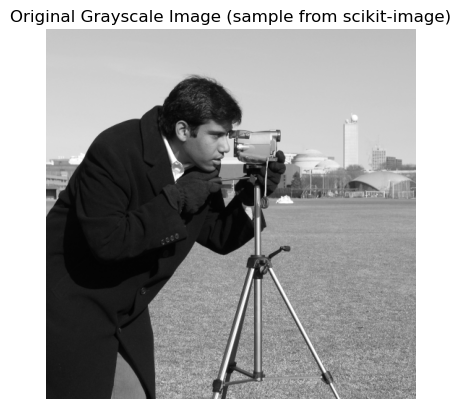

In [5]:
# Option 1: Use a sample image from scikit-image (no external file needed)
from skimage import data

# Load a sample grayscale image (e.g., 'camera' or 'astronaut')
image = data.camera()  # 512x512 grayscale image of a person
print(f"Image shape: {image.shape}")

# Normalise pixel values to [0, 1]
image = image.astype('float32') / 255.0

# Display original image
plt.imshow(image, cmap='gray')
plt.title("Original Grayscale Image (sample from scikit-image)")
plt.axis('off')
plt.show()

# If you want to use your own image, comment the above and uncomment the following:
# colored_image = cv2.imread("your_image_path.jpg")
# gray_image = cv2.cvtColor(colored_image, cv2.COLOR_BGR2GRAY)
# image = gray_image.astype('float32') / 255.0

## 2. Define Manual Filters

We define four simple filters that detect different features:
- **Filter 1**: detects horizontal patterns / right-side lines.
- **Filter 2**: detects horizontal patterns / left-side lines (negative of Filter 1).
- **Filter 3**: detects vertical patterns (transpose of Filter 1).
- **Filter 4**: detects vertical patterns (negative of Filter 3).

Visualising the manually defined filters


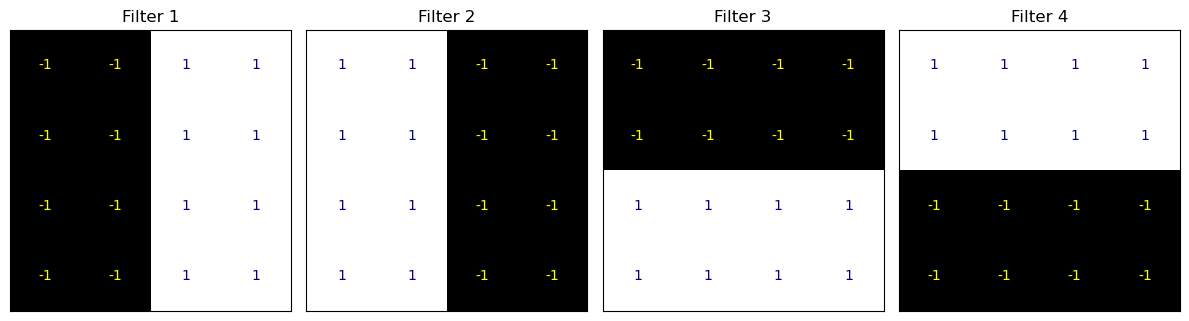

In [6]:
# Define the base filter values
filter_values = np.array([
    [-1, -1,  1,  1],
    [-1, -1,  1,  1],
    [-1, -1,  1,  1],
    [-1, -1,  1,  1]
])

# Create four filters
filter_1 = filter_values
filter_2 = -filter_1                     # negative of filter 1
filter_3 = filter_1.T                    # transpose of filter 1
filter_4 = -filter_3                     # negative of filter 3

filters = [filter_1, filter_2, filter_3, filter_4]

# Visualise the filters
print("Visualising the manually defined filters")
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for idx, f in enumerate(filters):
    ax = axes[idx]
    ax.imshow(f, cmap='gray')
    ax.set_title(f'Filter {idx+1}')
    ax.set_xticks([])
    ax.set_yticks([])
    # Annotate pixel values
    for x in range(f.shape[0]):
        for y in range(f.shape[1]):
            val = f[x, y]
            ax.annotate(f'{val}', xy=(y, x), ha='center', va='center',
                        color='yellow' if val < 0 else 'navy', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Visualising Activation Maps

We build a simple model with a single convolutional layer. We manually set the weights of the layer to our predefined filters and apply the convolution to the image. The output shows the activation map for each filter.

In [7]:
# Prepare input shape
input_shape = (image.shape[0], image.shape[1], 1)  # (height, width, channels)

# Build a model with a single convolutional layer with 1 filter
model = Sequential()
model.add(Conv2D(1, (4, 4), activation='relu', input_shape=input_shape))

print("Model defined.")

Model defined.


C:\Users\phabe\miniconda3\envs\ai_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
def apply_filter(img, filter_idx, filter_list, ax):
    """
    Apply a manually defined filter to the image and display the activation map.
    """
    # Reshape the filter to match Keras expectations: (height, width, input_channels, output_channels)
    manual_weights = [np.reshape(filter_list[filter_idx], (4, 4, 1, 1)), np.array([0])]

    # Set the weights of the convolutional layer
    model.layers[0].set_weights(manual_weights)

    # Prepare input: add batch and channel dimensions
    input_img = np.reshape(img, (1, img.shape[0], img.shape[1], 1))

    # Apply convolution
    prediction = model.predict(input_img, verbose=0)

    # Display activation map
    ax.imshow(np.squeeze(prediction), cmap='gray')
    ax.set_title(f'Filter {filter_idx+1}')
    ax.axis('off')

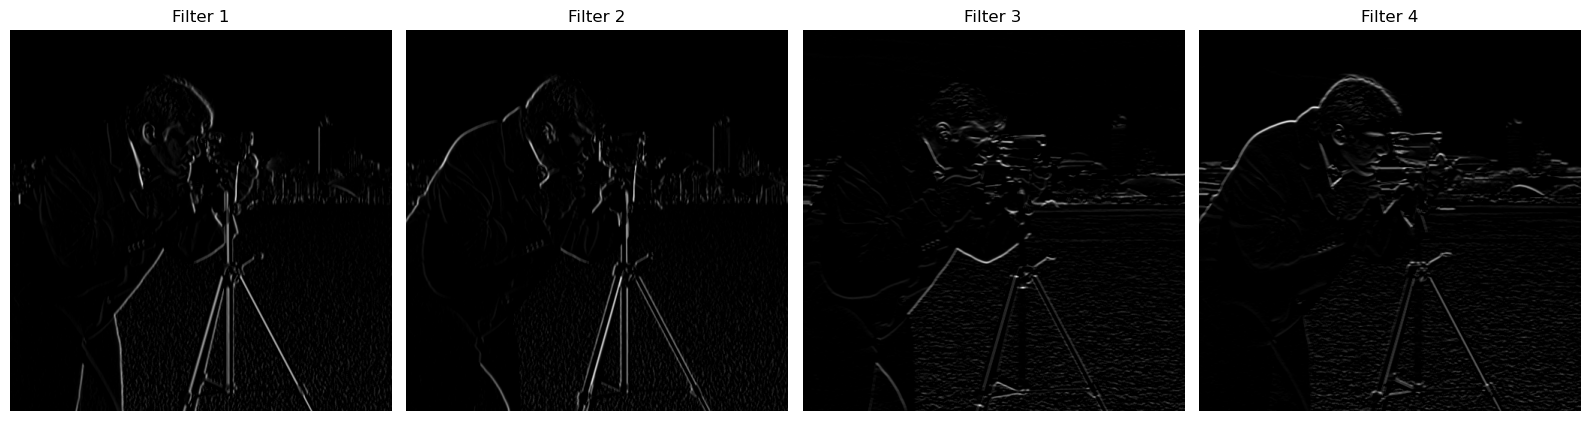

In [9]:
# Display the activation maps for each filter
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
for idx in range(len(filters)):
    apply_filter(image, idx, filters, axes[idx])

plt.tight_layout()
plt.show()

## 4. Discussion: What Do the Filters Detect?

Observe the activation maps produced by each filter:

- **Filter 1** – detects horizontal lines / edges on the right side of the image.
- **Filter 2** – detects horizontal lines / edges on the left side (opposite orientation).
- **Filter 3** – detects vertical lines / contours.
- **Filter 4** – detects vertical lines / contours (opposite orientation).

Each filter acts as a **feature detector**. In a trained CNN, the network learns these filters automatically from data, rather than having them manually defined.

### Key Observations:
- Different filters respond to different patterns: edges, textures, orientations.
- The activation maps highlight where each feature is present in the image.
- Convolutional layers build hierarchies: early layers detect simple edges, later layers detect complex shapes.

### Why This Matters:
- Understanding filters helps interpret what a CNN "sees".
- Visualising activation maps helps debug and explain model predictions.
- This technique can be applied to analyse what features a trained model has learned.

## Summary and Next Steps

**Accomplished:**
- Loaded and preprocessed a grayscale image (using scikit‑image's sample image).
- Manually defined four filters to detect different features.
- Built a simple convolutional model with a single layer.
- Applied each filter to the image and visualised the activation maps.
- Observed how different filters respond to different patterns.

**Key Insights:**
- Convolutional filters are feature detectors that respond to specific patterns.
- Filters can be designed to detect edges, lines, textures, or orientations.
- A CNN automatically learns these filters from data, eliminating the need for manual design.
- Visualising activation maps helps interpret what a CNN has learned.
- Early layers learn simple features (edges, corners); deeper layers learn more complex patterns.
- The warning about TensorFlow GPU on Windows is harmless – the notebook runs on CPU.

**Suggested Next Steps:**
1. **Visualise filters from a pre‑trained CNN** – e.g., using a VGG or ResNet model.
2. **Visualise activation maps from deeper layers** – see how features become more abstract.
3. **Visualise what a CNN learns** – use techniques like Gradient‑weighted Class Activation Mapping (Grad‑CAM).
4. **Apply to your own image** – download an image and test the filters on it.
5. **Implement convolution from scratch** – understand the mathematical operation.
6. **Experiment with different filter sizes** – try 3×3, 5×5, or larger filters.
7. **Visualise the effect of stride and padding** – see how these parameters affect the output.

**Reflection:**
This notebook provides a hands‑on understanding of what convolutional filters do. The manual filters illustrate the concept, while the activation maps show how the network responds to different features. This insight is fundamental to understanding how CNNs work and why they are so effective for image tasks. The visualisation approach can be extended to analyse the internal representations of any trained CNN model, making it a valuable tool for model interpretation and debugging.